In [65]:
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [2]:
path = kagglehub.dataset_download('maharshipandya/-spotify-tracks-dataset')

print('Path to dataset files:', path)


Using Colab cache for faster access to the '-spotify-tracks-dataset' dataset.
Path to dataset files: /kaggle/input/-spotify-tracks-dataset


In [3]:
df = pd.read_csv(path+ '/dataset.csv')

In [4]:
print (df.shape)
df.head()

(114000, 21)


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


The dataset is really big, it has 114,000 rows and 21 columns.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

In [6]:
print (df['track_genre'].nunique())
print (df['track_genre'].unique())

114
['acoustic' 'afrobeat' 'alt-rock' 'alternative' 'ambient' 'anime'
 'black-metal' 'bluegrass' 'blues' 'brazil' 'breakbeat' 'british'
 'cantopop' 'chicago-house' 'children' 'chill' 'classical' 'club' 'comedy'
 'country' 'dance' 'dancehall' 'death-metal' 'deep-house' 'detroit-techno'
 'disco' 'disney' 'drum-and-bass' 'dub' 'dubstep' 'edm' 'electro'
 'electronic' 'emo' 'folk' 'forro' 'french' 'funk' 'garage' 'german'
 'gospel' 'goth' 'grindcore' 'groove' 'grunge' 'guitar' 'happy'
 'hard-rock' 'hardcore' 'hardstyle' 'heavy-metal' 'hip-hop' 'honky-tonk'
 'house' 'idm' 'indian' 'indie-pop' 'indie' 'industrial' 'iranian'
 'j-dance' 'j-idol' 'j-pop' 'j-rock' 'jazz' 'k-pop' 'kids' 'latin'
 'latino' 'malay' 'mandopop' 'metal' 'metalcore' 'minimal-techno' 'mpb'
 'new-age' 'opera' 'pagode' 'party' 'piano' 'pop-film' 'pop' 'power-pop'
 'progressive-house' 'psych-rock' 'punk-rock' 'punk' 'r-n-b' 'reggae'
 'reggaeton' 'rock-n-roll' 'rock' 'rockabilly' 'romance' 'sad' 'salsa'
 'samba' 'sertanejo' '

The dataset has 114 unique genres.


In [7]:
df.isnull().sum()

,0
Unnamed: 0,0
track_id,0
artists,1
album_name,1
track_name,1
popularity,0
duration_ms,0
explicit,0
danceability,0
energy,0


Even though the dataset is really big only 3 values are missing.

In [8]:
df.dropna(inplace = True)
df.groupby('track_genre')['popularity'].mean().sort_values(ascending = False).head(10)

,popularity
track_genre,
pop-film,59.283000
k-pop,56.952953
chill,53.651000
sad,52.379000
grunge,49.594000
indian,49.539000
anime,48.772000
emo,48.128000
sertanejo,47.866000


Apparently the most popular genre is pop-film with a mean of 59.28, followed by k-pop music with 56.95.

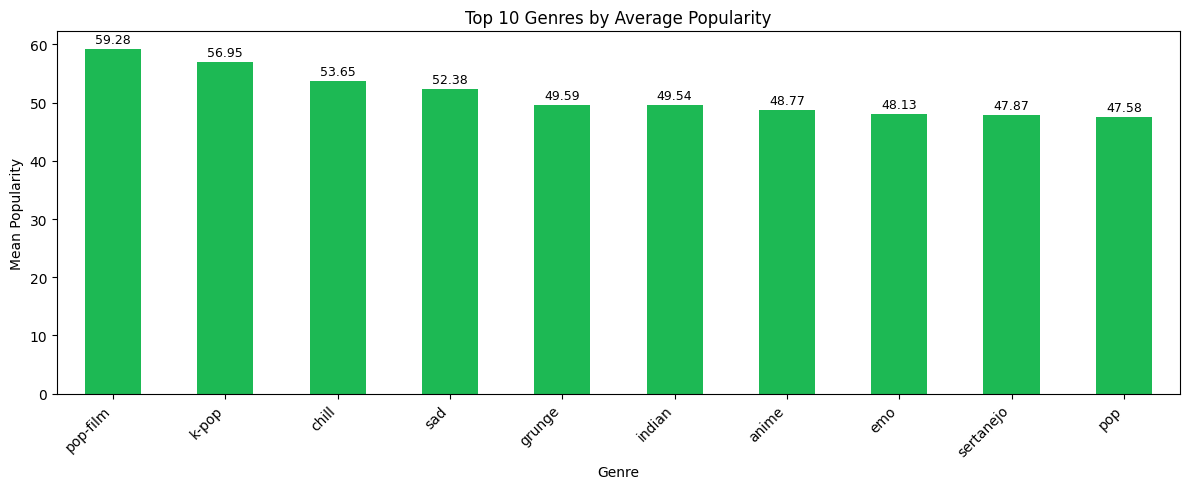

In [9]:
top10 = df.groupby('track_genre')['popularity'].mean().sort_values(ascending = False).head(10)
top10.plot(kind= 'bar', figsize = (12, 5),  color='#1DB954')
plt.title('Top 10 Genres by Average Popularity')
plt.xlabel('Genre')
plt.ylabel('Mean Popularity')
plt.xticks(rotation=45, ha= 'right')
for i, v in enumerate(top10.values):
    plt.text(i, v+0.5, f"{v:.2f}", ha= 'center', va= 'bottom', fontsize = 9)
plt.tight_layout()
plt.show()

The bar chart confirms that pop-film and k-pop dominate Spotify in terms of average popularity with scores a bit higher than other genres. This suggests that music tied to visual media and strong international fanbases tends to perform better on the platform.


<function matplotlib.pyplot.show(close=None, block=None)>

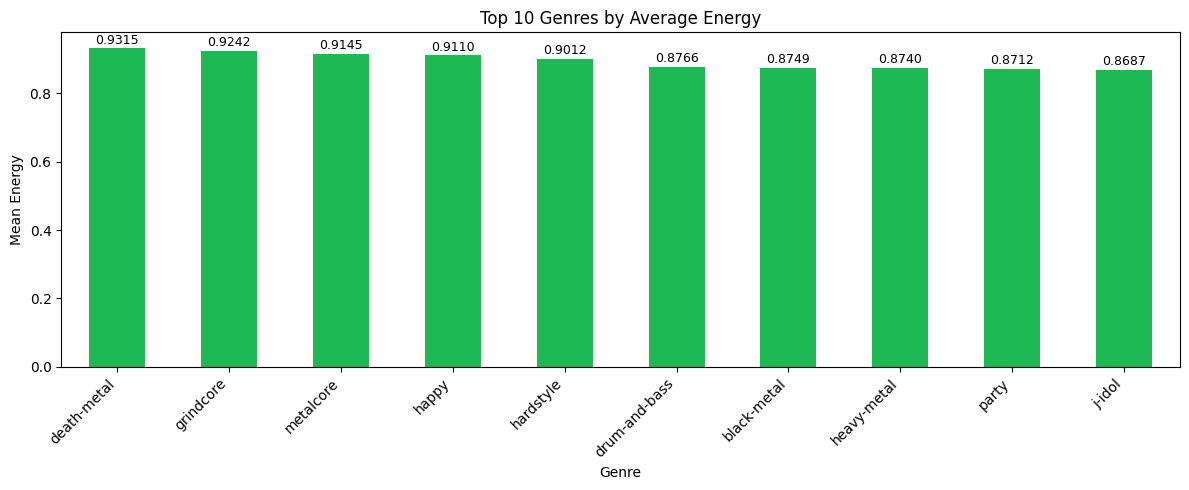

In [10]:
top10_energy = df.groupby('track_genre')['energy'].mean().sort_values(ascending = False).head(10)
top10_energy.plot(kind= 'bar', figsize = (12, 5),  color='#1DB954')
plt.title('Top 10 Genres by Average Energy')
plt.xlabel('Genre')
plt.ylabel('Mean Energy')
plt.xticks(rotation=45, ha= 'right')
for i , v in enumerate(top10_energy.values):
    plt.text(i, v+0.005, f'{v:.4f}', ha= 'center', va= 'bottom', fontsize = 9)
plt.tight_layout()
plt.show

The most energetic genres are dominated by metal subgenres (death-metal, grindcore, metalcore), with average energy scores above 0.90. Notably, these genres do not overlap with most popular ones, suggesting that high energy does not necessarily translate into mainstream popularity on Spotify.

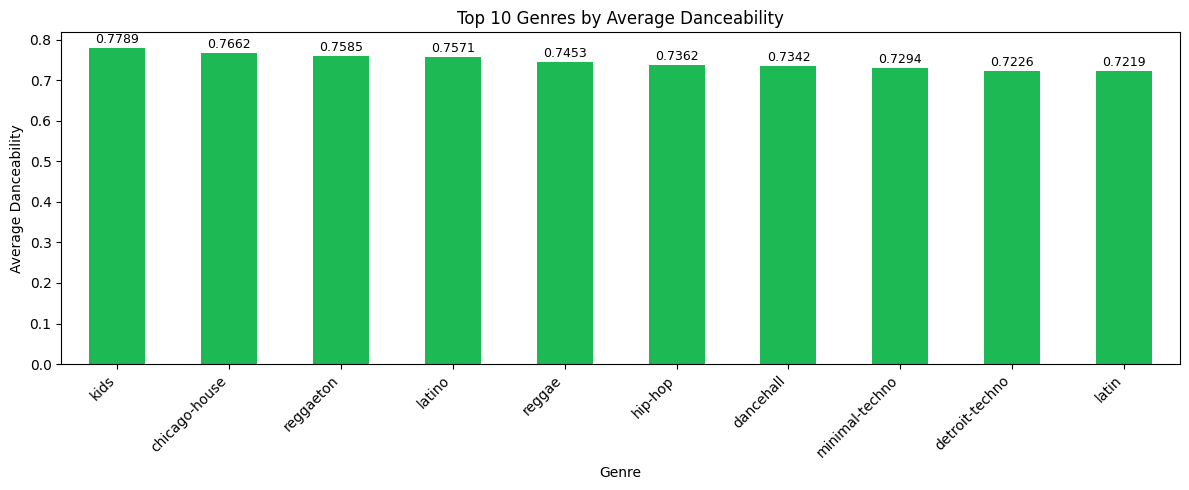

In [11]:
top10_dance = df.groupby('track_genre')['danceability'].mean().sort_values(ascending = False).head(10)

top10_dance.plot(kind= 'bar', figsize = (12, 5),  color='#1DB954')
plt.title('Top 10 Genres by Average Danceability')
plt.xlabel('Genre')
plt.ylabel('Average Danceability')
plt.xticks(rotation=45, ha= 'right')
for i , v in enumerate(top10_dance):
    plt.text(i, v+0.005, f"{v:.4f}", ha= 'center', va= 'bottom', fontsize = 9)
plt.tight_layout()
plt.show()

The most danceable genres are dominated by rhythmic and Latin-influenced styles, kids music tops the chart (0.78), followed by chicago-house, reggaeton, latino and reggae. This contrasts sharply with the high-energy metal genres, confirming that danceability and energy measure two very different musical qualities.

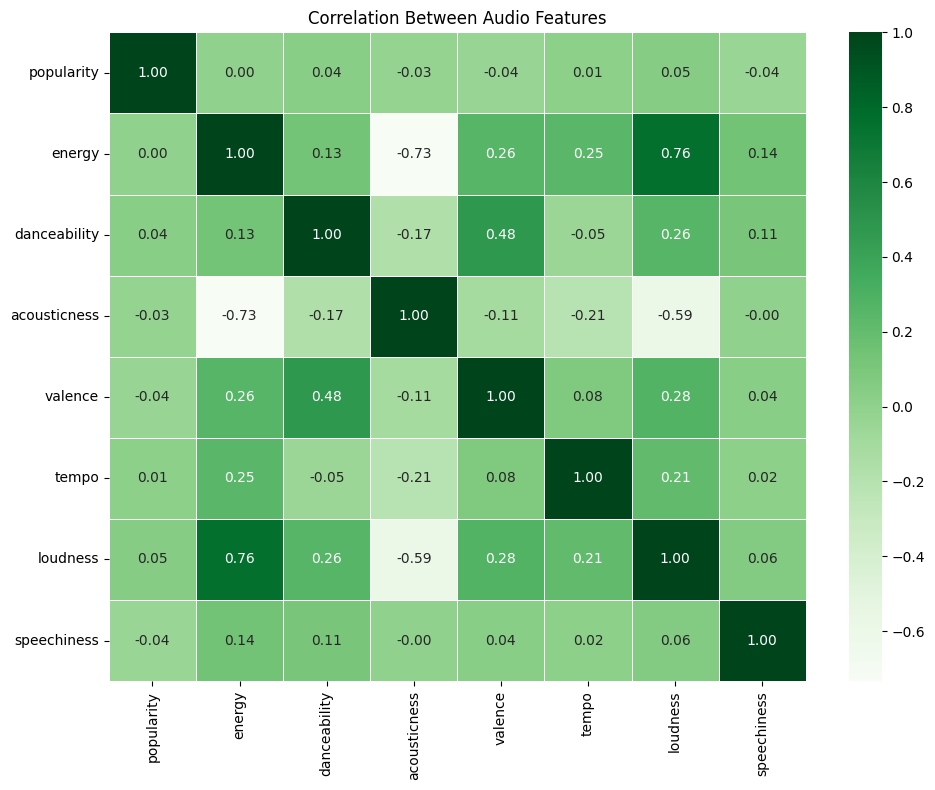

In [12]:
numeric_cols = ['popularity', 'energy', 'danceability',
                'acousticness', 'valence', 'tempo',
                'loudness', 'speechiness']

corr = df[numeric_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt='.2f',
            cmap='Greens', linewidths=0.5)
plt.title('Correlation Between Audio Features')
plt.tight_layout()
plt.show()

The heatmap reveals several interesting relationships between audio features:
The strongest positive correlation is between energy and loudness (0.76) — louder songs tend to be more energetic, which makes intuitive sense.
The strongest negative correlation is between acousticness and energy (-0.73), meaning acoustic songs are typically low energy. A similar inverse relationship exists between acousticness and loudness (-0.59).
Danceability and valence show a moderate positive correlation (0.48) — more danceable songs tend to sound happier and more positive.
Surprisingly, tempo and energy only correlate at 0.25 — suggesting that a song's speed alone does not determine how energetic it feels.
Most importantly, popularity shows almost zero correlation with any audio feature. This suggests that what makes a song popular on Spotify goes far beyond its sonic characteristics — factors like artist fame, playlist placement, and cultural trends likely play a much bigger role.

Before analyzing the most popular songs, I noticed that the dataset contains duplicate entries — the same track appears multiple times across different genres. I removed duplicates based on track name and artist to ensure each song is counted only once.

In [13]:
top_songs = df[['track_name', 'artists', 'popularity',
                'energy', 'danceability', 'valence']].drop_duplicates(subset=['track_name', 'artists']).sort_values('popularity', ascending=False).head(20)

top_songs

,track_name,artists,popularity,energy,danceability,valence
20001,Unholy (feat. Kim Petras),Sam Smith;Kim Petras,100,0.472,0.714,0.238
51664,"Quevedo: Bzrp Music Sessions, Vol. 52",Bizarrap;Quevedo,99,0.782,0.621,0.550
67356,La Bachata,Manuel Turizo,98,0.679,0.835,0.850
20008,I'm Good (Blue),David Guetta;Bebe Rexha,98,0.965,0.561,0.304
67358,Me Porto Bonito,Bad Bunny;Chencho Corleone,97,0.712,0.911,0.425
67359,Tití Me Preguntó,Bad Bunny,97,0.715,0.650,0.187
67559,Efecto,Bad Bunny,96,0.475,0.801,0.234
20000,Under The Influence,Chris Brown,96,0.690,0.733,0.310
79000,I Ain't Worried,OneRepublic,96,0.797,0.704,0.825
81052,As It Was,Harry Styles,95,0.731,0.520,0.662


The top 10 most popular songs are dominated by Latin artists — Bad Bunny appears 5 times in the top 20 alone. Interestingly, the most popular song (Unholy by Sam Smith, popularity: 100) has relatively low energy (0.472) and valence (0.238), confirming once again that audio features alone don't predict popularity. Danceability tends to be high across most top tracks, suggesting it may play a small role in mainstream appeal.

Since we already know which genres are the most popular one, I decided to explore a new field ("valence") to find which genres are the most happy and which are not.

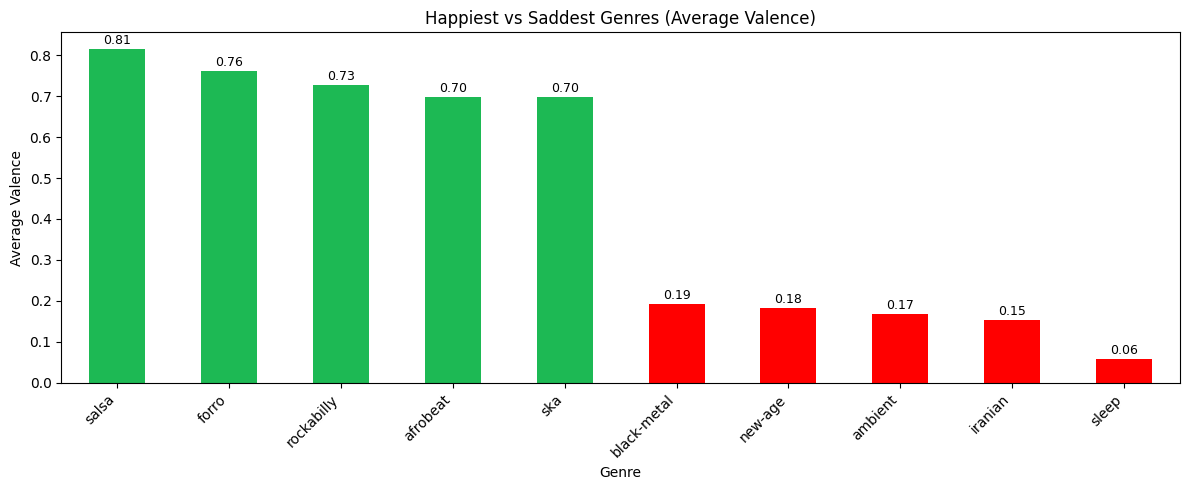

In [14]:
top10_valence = df.groupby('track_genre')['valence'].mean().sort_values(ascending=False)

top_5 = top10_valence.head(5)
bottom_5 = top10_valence.tail(5)

top_bottom = pd.concat([top_5, bottom_5])

colors = ['#1DB954'] * 5 + ['red'] * 5

top_bottom.plot(kind='bar', figsize=(12,5), color=colors)
plt.title('Happiest vs Saddest Genres (Average Valence)')
plt.xlabel('Genre')
plt.ylabel('Average Valence')
plt.xticks(rotation=45, ha='right')

for i, v in enumerate(top_bottom.values):
    plt.text(i, v + 0.005, f'{v:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

Now that we know which genres are the happiest ones and which are not, I decided to explore if valence impacts also on popularity.

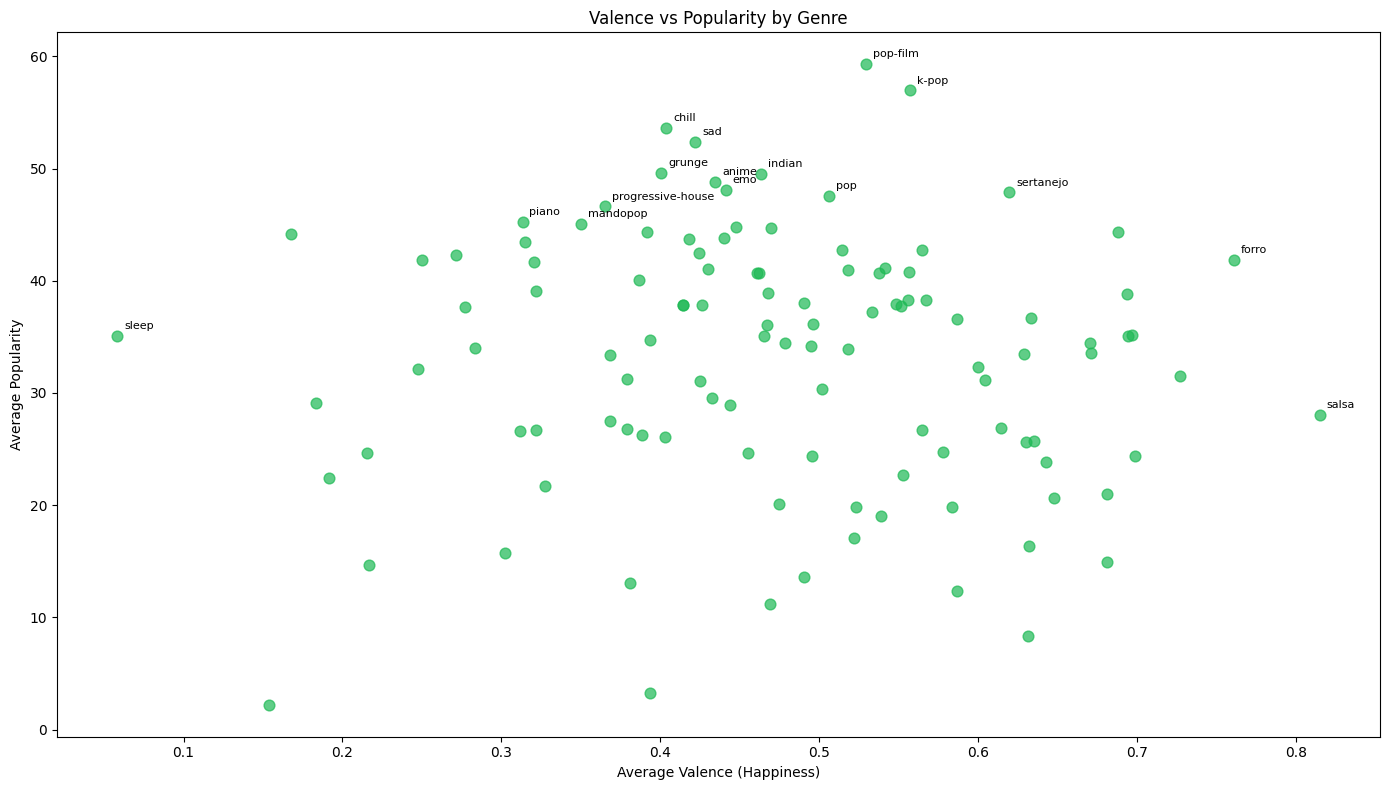

In [15]:
genre_stats = df.groupby('track_genre').agg(
    avg_valence=('valence', 'mean'),
    avg_popularity=('popularity', 'mean')
).reset_index()
plt.figure(figsize=(14,8))
plt.scatter(genre_stats['avg_valence'], genre_stats['avg_popularity'],
            alpha=0.7,  color='#1DB954', s=60)

for _, row in genre_stats.iterrows():
    if row['avg_popularity'] > 45 or row['avg_valence'] > 0.75 or row['avg_valence'] < 0.15:
        plt.annotate(row['track_genre'],
                    (row['avg_valence'], row['avg_popularity']),
                    textcoords="offset points",
                    xytext=(5, 5),
                    fontsize=8)

plt.title('Valence vs Popularity by Genre')
plt.xlabel('Average Valence (Happiness)')
plt.ylabel('Average Popularity')
plt.tight_layout()
plt.show()

As seen before, "pop-film" and "k-pop" are extremely popular, but also on average somehow lively. The sleep genre even though it has an extremely low valence (as one wouldn't be able to sleep otherwise), it remains a medium-popular genre, this means that a lot of people use music to sleep. Meanwhile "salsa", it's extremely lively compared to its competitor, but it isn't that popular; also "chill" and "sad" genre even though they have an average valence, they are extremely popular, does this mean that people feel sad often, or perhaps that melancholic music resonates more deeply with listeners?
The "piano" genre it's quite popular, but on average songs played on piano have low valence, suggesting that the piano genre leans toward more emotional and melancholic compositions.


To explore if duration impacts on popularity, i decided to create a new column that converts duration from milliseconds to minutes, then filtered songs between 1 and 10 minutes, and analyzed using a box plot.

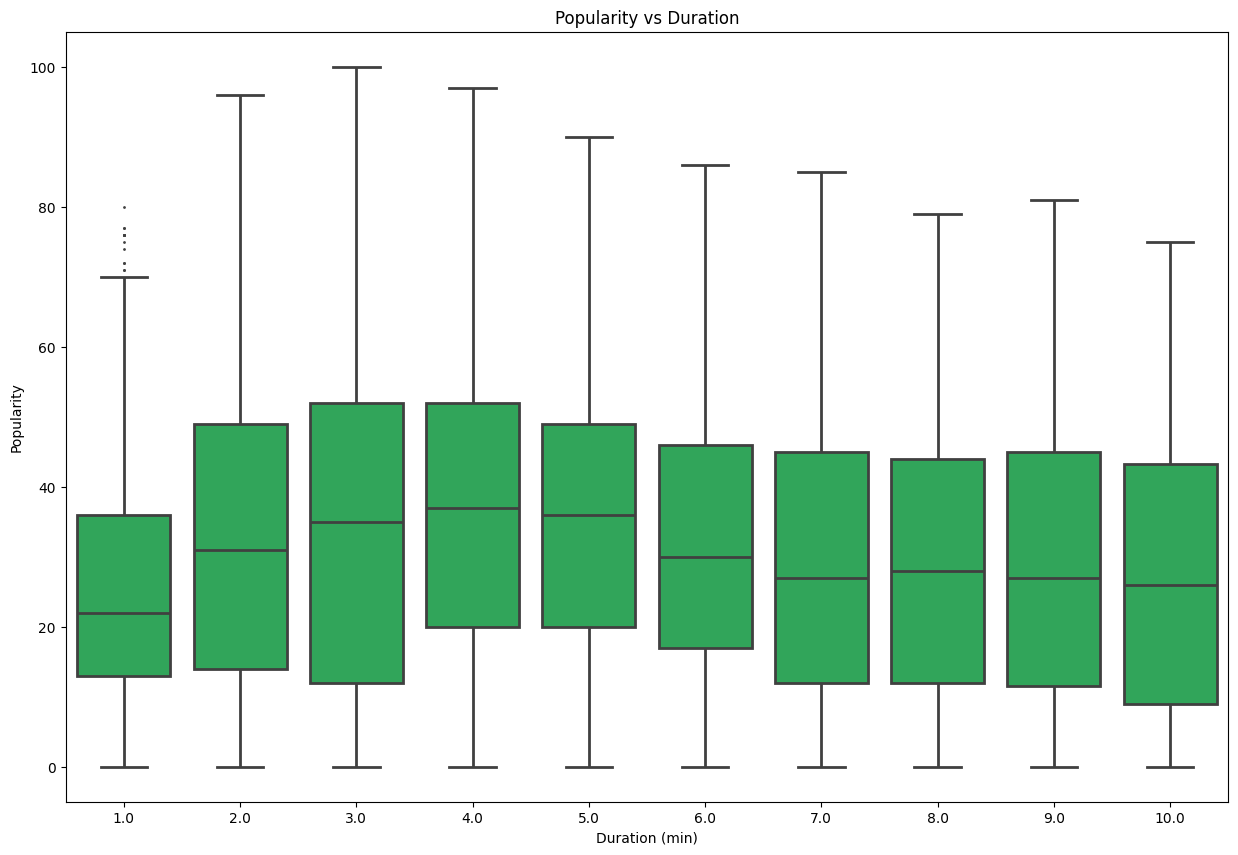

In [16]:
df['duration_min'] = round(df['duration_ms']/60000)
df_filtered = df[(df['duration_min'] >= 1) & (df['duration_min'] <= 10)]
plt.figure(figsize=(15,10))
sns.boxplot(x= df_filtered['duration_min'], y = df_filtered['popularity'], color = '#1DB954' ,width=0.8, gap=0, whis=1.5, linecolor='auto', linewidth=2, fliersize=1 )
plt.xlabel('Duration (min)')
plt.ylabel('Popularity')
plt.title('Popularity vs Duration')
plt.show()

Songs between 3 and 4 minutes tend to have the highest median popularity, with a range that goes respectively from 35 to 37.
Songs shorter than 2 minutes show lower popularity, probably due to intros or skits during albums.
Beyond 6 minutes, median popularity gradually decreases, showing that listeners are more likely to prefer songs that don't last that long.

In [17]:
df['explicit'].value_counts()
df['explicit_label'] = df['explicit'].map(lambda x: "Explicit" if x == True else "Clean")
df[['track_name', 'explicit', 'explicit_label']].head()

,track_name,explicit,explicit_label
0,Comedy,False,Clean
1,Ghost - Acoustic,False,Clean
2,To Begin Again,False,Clean
3,Can't Help Falling In Love,False,Clean
4,Hold On,False,Clean


In [18]:
df['energy_label'] = df['energy'].map(lambda x: "High Energy" if x > 0.8 else "Medium Energy" if x >= 0.5 else "Low Energy")

df[['track_name', 'energy', 'energy_label']].head(10)

,track_name,energy,energy_label
0,Comedy,0.4610,Low Energy
1,Ghost - Acoustic,0.1660,Low Energy
2,To Begin Again,0.3590,Low Energy
3,Can't Help Falling In Love,0.0596,Low Energy
4,Hold On,0.4430,Low Energy
5,Days I Will Remember,0.4810,Low Energy
6,Say Something,0.1470,Low Energy
7,I'm Yours,0.4440,Low Energy
8,Lucky,0.4140,Low Energy
9,Hunger,0.6320,Medium Energy


In the previous cells I created two new columns: `explicit_label` (Explicit / Clean)
and `energy_label` (High / Medium / Low Energy). Let's now explore whether these
characteristics have any impact on a track's popularity.


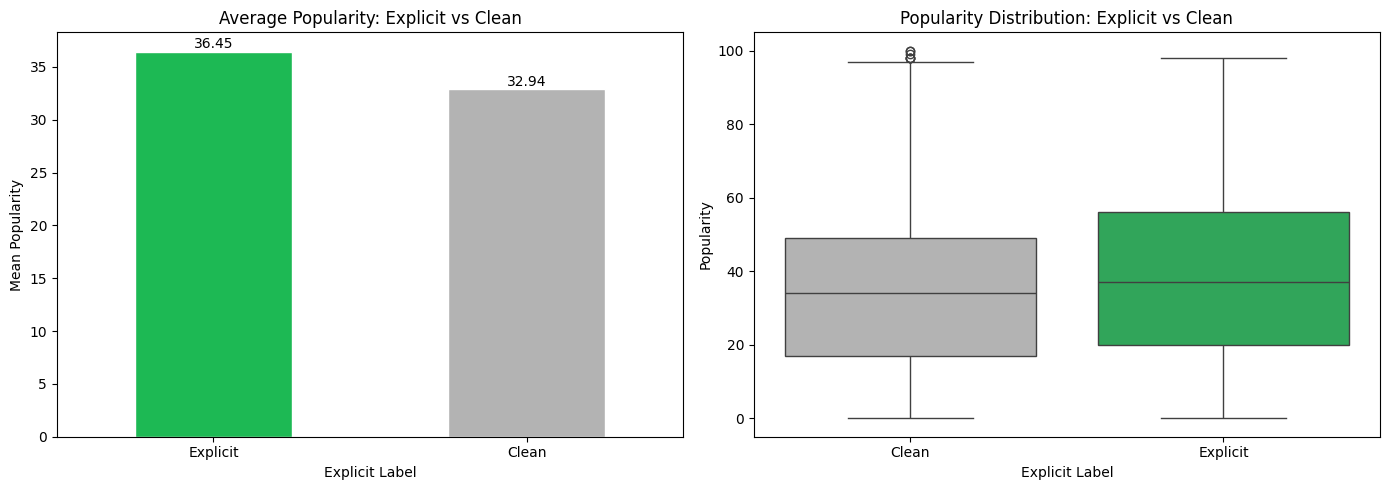

In [19]:
explicit_pop = df.groupby('explicit_label')['popularity'].mean().sort_values(ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
explicit_pop.plot(kind='bar', ax=axes[0], color=['#1DB954', '#b3b3b3'], edgecolor='white')
axes[0].set_title('Average Popularity: Explicit vs Clean')
axes[0].set_xlabel('Explicit Label')
axes[0].set_ylabel('Mean Popularity')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
for i, v in enumerate(explicit_pop.values):
    axes[0].text(i, v + 0.3, f'{v:.2f}', ha='center', fontsize=10)
sns.boxplot(x='explicit_label', y='popularity', data=df, hue='explicit_label', palette ={'Explicit': '#1DB954', 'Clean': '#b3b3b3'}, ax=axes[1])
axes[1].set_title('Popularity Distribution: Explicit vs Clean')
axes[1].set_xlabel('Explicit Label')
axes[1].set_ylabel('Popularity')
plt.tight_layout()
plt.show()

Explicit tracks are slightly more popular on average than clean ones.
But with the boxplot I got some more info, since explicit tracks show much wider distribution, meaning that there is a greater variance in popularity, some are extremely popular while others are barely listened.
Clean tracks on the other hand, tends to cluster around lower popularity values, but with less variance overeall.

This difference is probably not caused by the explicit content, but probably that genres with more explicit contents(rap, hip-hop) are the most streamed on Spotify.

I will explore this in the next session.

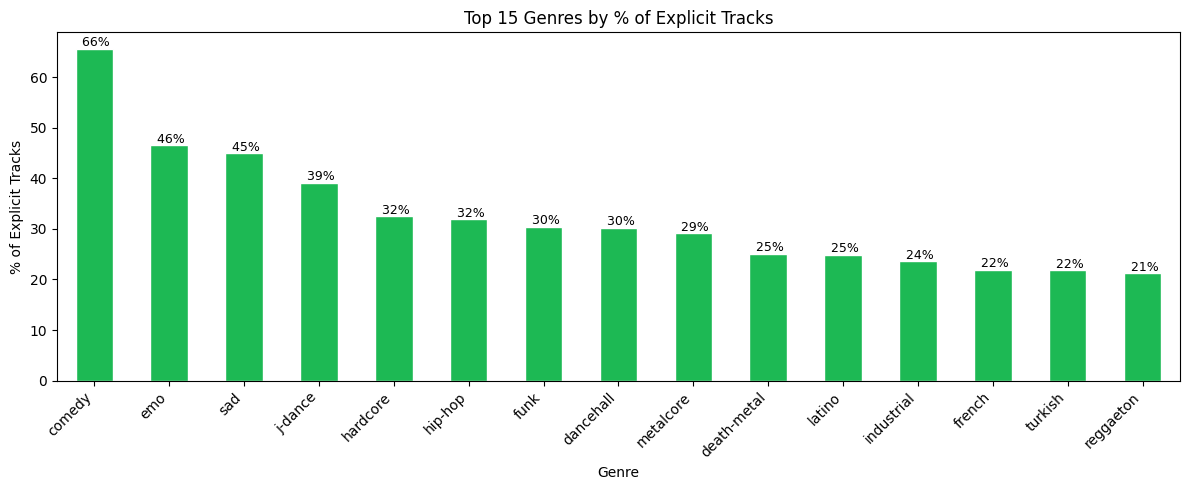

In [20]:
explicit_by_genre = df.groupby('track_genre')['explicit'].mean().sort_values(ascending=False).head(15)
plt.figure(figsize= (12,5))
explicit_by_genre.mul(100).plot(kind='bar', color='#1DB954', edgecolor='white')
plt.title('Top 15 Genres by % of Explicit Tracks')
plt.xlabel('Genre')
plt.ylabel('% of Explicit Tracks')
plt.xticks(rotation=45, ha='right')
for i,v in enumerate(explicit_by_genre):
  plt.text(i, v*100 + 0.5, f'{v*100: .0f}%', ha='center', fontsize= 9)
plt.tight_layout()
plt.show()

As We can see comedy tops the chart with 66% of explicit tracks, that at first sight might seem surprising but it kinda make sense if you think about monologues and satirical songs, where explicit language is often part of this style.

Emo and sad follow closely at 46% and 45% respectively.
Now things starts to seem really interesting because if we combine with what I found earlier: the sad genre was one of the most popular on Spotify even if it had an average valence.
Now we can see that is also heavily explicit, suggesting that the popularity might be a combination of melancholic, raw and direct language themes.

Hip-hop, even though what I assumed, It has only 32%, meaning that the majority of hip-hop tracks in this dataset are actually clean.

This is a reminder to never judge a book by its cover.


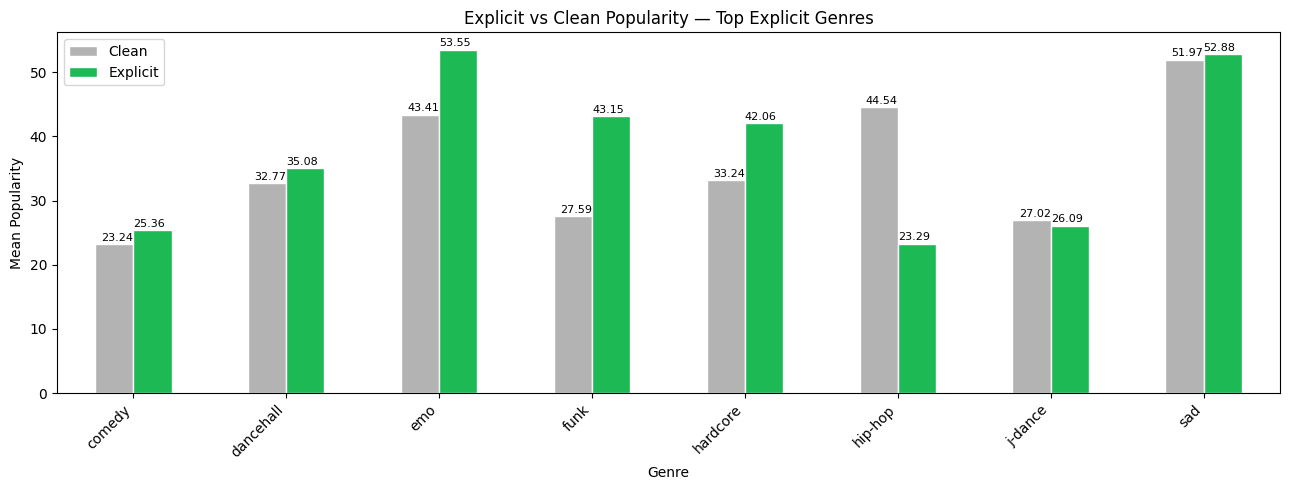

In [21]:
top_explicit_genres = explicit_by_genre.head(8).index.tolist()

df_top = df[df['track_genre'].isin(top_explicit_genres)]
pivot = df_top.groupby(['track_genre', 'explicit_label'])['popularity'].mean().unstack()

pivot.plot(kind='bar', figsize=(13, 5), color=['#b3b3b3', '#1DB954'], edgecolor='white')
plt.title('Explicit vs Clean Popularity — Top Explicit Genres')
for i, v in enumerate(pivot.index):
    plt.text(i, pivot.loc[v, 'Explicit'] + 0.5, f'{pivot.loc[v, "Explicit"]:.2f}', ha='left', fontsize=8)
    plt.text(i, pivot.loc[v, 'Clean'] + 0.5, f'{pivot.loc[v, "Clean"]:.2f}', ha='right', fontsize=8)
plt.xlabel('Genre')
plt.ylabel('Mean Popularity')
plt.xticks(rotation=45, ha='right')
plt.legend(title='')
plt.tight_layout()
plt.show()

Ok, if we look to individual genre, it's more clear.

For most genres, like comedy, dancehall and j-dance the difference between explicit and clean popularity is very minimal, suggesting that explicit contents not always bring more popularity within this genres.

Emo is probably one of the ones that really stands out, in this genre explicit content outperforms clean ones the most. If we combine the fact that emo stands at 46% explicit, second only to comedy, this suggest that explicit language is heavily tied to the identity of the genre and likely to contribute to its popularity.

Funk also has a similar pattern with a favorable gap for explicit tracks.

The most surprising finding however is hip-hop that contrary to common assumption (or at least mine), clean tracks are significantly more popular than explicit ones. This somehow reflects the fact that clean versions reach a wider audience on Spotify, appearing in family, work and radio playlists.

Then there's sad genre that confirms what we saw throughout this analysis, it's really popular in both versions, with clean and explicit tracks performing almost equally well.

In [22]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

Before running K-Means, we need to find the optimal number of clusters.
To do this we use the Elbow Method, so we run K-Means for different values of K ( in my case from 2 to 10) and plot the inertia for each one.
Inertia needs to discover how compact the clusters are:
the lower the inertia, the closer the points are to their cluster center.

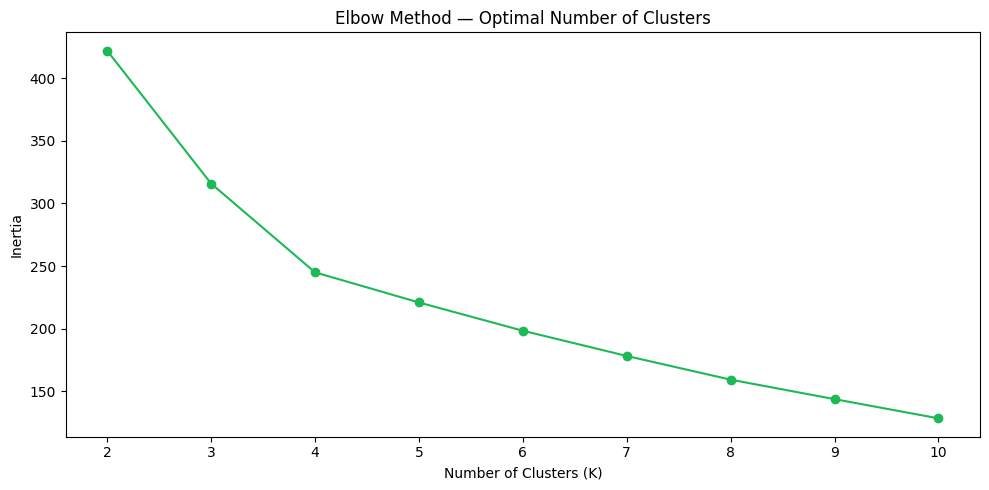

In [48]:
genre_features = df.groupby('track_genre')[['energy', 'danceability', 'valence', 'acousticness', 'tempo', 'loudness']].mean()

scaler = StandardScaler()
genre_scaled = scaler.fit_transform(genre_features)

inertia = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(genre_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(k_range, inertia, marker='o', color='#1DB954')
plt.title('Elbow Method — Optimal Number of Clusters')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.tight_layout()
plt.show()

As you can see the curve drops sharply from K=2 to K=4, then begins to flatten out a bit.
This "elbow" point suggests that adding more clusters beyond 4 brings
diminishing returns, the clusters don't get better.
So I'll use K=4 for my analysis.

In [59]:
km = KMeans(n_clusters=4, random_state=42, n_init=10)
genre_features['cluster'] = km.fit_predict(genre_scaled)

for i in range(4):
    print(f"\nCluster {i}:")
    print(genre_features[genre_features['cluster'] == i].index.tolist())


cluster_names = {
    0: 'Rhythmic & Dance',
    1: 'Melodic & Emotional',
    2: 'High Energy & Intensity',
    3: 'Calm & Atmospheric'
}

genre_features['cluster_name'] = genre_features['cluster'].map(cluster_names)


Cluster 0:
['afrobeat', 'alternative', 'chicago-house', 'children', 'dance', 'dancehall', 'deep-house', 'detroit-techno', 'disco', 'edm', 'electro', 'electronic', 'emo', 'forro', 'funk', 'hip-hop', 'house', 'j-dance', 'j-pop', 'k-pop', 'kids', 'latin', 'latino', 'minimal-techno', 'pagode', 'party', 'pop', 'r-n-b', 'reggae', 'reggaeton', 'rock', 'rockabilly', 'salsa', 'samba', 'sertanejo', 'ska', 'spanish', 'swedish', 'synth-pop', 'trip-hop']

Cluster 1:
['acoustic', 'anime', 'bluegrass', 'blues', 'brazil', 'british', 'cantopop', 'chill', 'comedy', 'country', 'folk', 'french', 'german', 'gospel', 'honky-tonk', 'idm', 'indian', 'indie', 'indie-pop', 'jazz', 'malay', 'mandopop', 'mpb', 'pop-film', 'psych-rock', 'rock-n-roll', 'sad', 'show-tunes', 'singer-songwriter', 'songwriter', 'soul', 'study', 'tango', 'turkish', 'world-music']

Cluster 2:
['alt-rock', 'black-metal', 'breakbeat', 'club', 'death-metal', 'drum-and-bass', 'dub', 'dubstep', 'garage', 'goth', 'grindcore', 'groove', 'grung

The four groups that K-Means found are really interesting because they match real music types well.

- Cluster 0 (Rythmic & Dance) is for music that is good for dancing: electronic, latin, hip-hop pop. These types of music are about the beat and moving your body.

- Cluster 1 (Melodic & Emotional) is for music that is emotional and has nice melodies: folk, soul, jazz, sad, singer-songwriter. This music is about the tune, the words and how it makes you feel.

- Cluster 2 (High Energy & Intensity) is for music that's loud and full of energy: metal, punk, hardcore, dubstep. This music is fast, loud and strong.

- Cluster 3 (Calm & Athmospheric) is for music that's calm and peaceful: ambient, classical, sleep, piano. This music is quiet helps you think and is nice to listen to.

What is really cool about this is that K-Means figured out these groups by only looking at numbers like how much energy the music has, if you can dance to it if it is happy or sad if it is loud or quiet. K-Means did not know anything about music.

Now that I have identified and labeled the four clusters, I wanted to visualize them using a radar chart.
Each axis represents one of the six features
used for clustering:energy, danceability, valence, acousticness, tempo and loudness.
All values have been normalized between 0 and 1 using Min-Max Scaling.

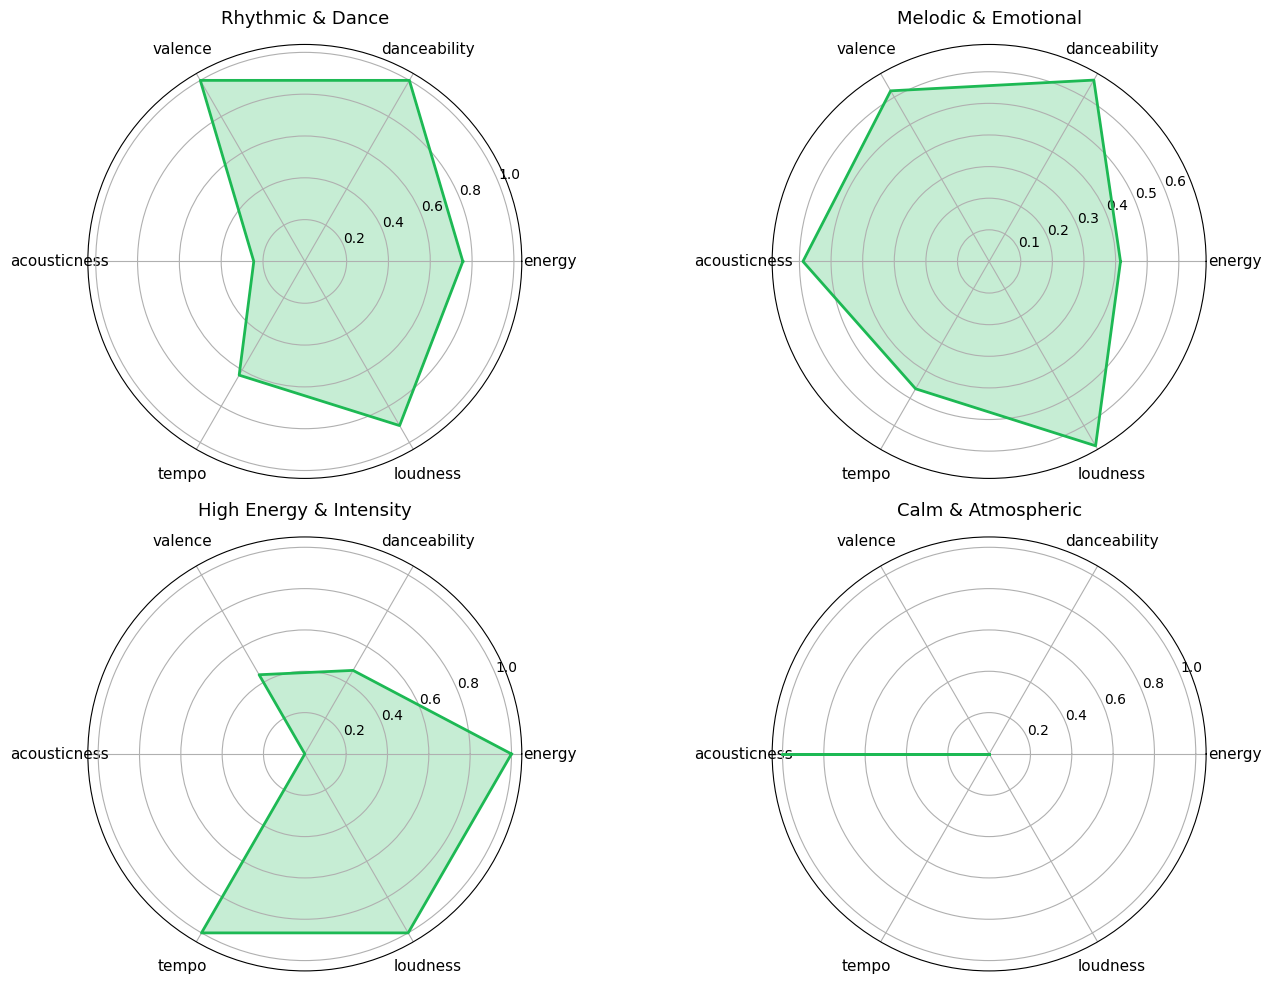

In [88]:
features = ['energy', 'danceability', 'valence', 'acousticness', 'tempo', 'loudness']
cluster_means = genre_features.groupby('cluster_name')[features].mean()

cluster_means_normalized = (cluster_means - cluster_means.min()) / (cluster_means.max() - cluster_means.min())

fig = plt.figure(figsize=(14, 10))

angles = np.linspace(0, 2 * np.pi, len(features), endpoint=False).tolist()
angles += angles[:1]


for i, (cluster_num, cluster_name) in enumerate(cluster_names.items()):
    ax = fig.add_subplot(2, 2, i+1, polar=True)

    values = cluster_means_normalized.loc[cluster_name].tolist()
    values += values[:1]

    ax.plot(angles, values, color='#1DB954', linewidth=2)
    ax.fill(angles, values, color='#1DB954', alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(features, size=11)
    ax.tick_params(pad=10)
    ax.set_title(cluster_name, size=13, pad=15)

plt.tight_layout()
plt.show()

The radar charts show us what the K-Means found from the numbers.

Rhythmic & Dance music stands out because it has valence and danceability. This means it is energetic music that is made for people to move to. However it is not very acoustic.

Melodic & Emotional music is the balanced type. It does not have any values. This suggests that this music is focused on melody and lyrics than being intense or rhythmic.

The High Energy & Intensity music has a lot of energy is very loud and has a tempo. It also has no acousticness. This makes sense because genres like metal and hardcore rarely use instruments.

The Calm & Atmospheric music scores low on every feature.. This is not a bad thing. It is actually what we would expect from music that is meant to be quiet and fade into the background.

The profiles that were created match how a listener would naturally describe these genres of music. The Rhythmic & Dance music, the Melodic & Emotional music, the High Energy & Intensity music and the Calm & Atmospheric music all sound like what they're supposed to be.

Nothing new or strange unfortunately :(
